# Premier League Match Prediction - Full-Feature PCA and Autoencoder Reduction

## Objective

This notebook uses all numeric pre-match features from `epl_features.csv` and compares three feature representations:

- Original full numeric feature set
- PCA-reduced features
- Autoencoder-reduced features

The same chronological modeling analysis is then run on those representations. Models are tuned with Bayesian optimization using validation accuracy as the primary objective and log loss as the secondary tie-breaker.

XGBoost is included as an optional model. If `xgboost` is not installed in the environment, the notebook skips it and prints a clear message.

## 1. Modeling Rules

- Target: `target_result_encoded`, where `0 = Home Win`, `1 = Draw`, and `2 = Away Win`.
- Inputs: all numeric pre-match features from `epl_features.csv`, excluding identifiers, target columns, and same-match result columns.
- Split:
  - Train: `2016_2017` through `2023_2024`
  - Validation: `2024_2025`
  - Test: `2025_2026`
- PCA and autoencoders are fit on training rows only during validation tuning.
- Final test evaluation refits the selected reducer/model on train + validation rows, then evaluates once on `2025_2026`.

## 2. Imports and Data Load

In [1]:
from itertools import product
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, log_loss, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")

DATA_PATH = Path("../data/processed/epl_features.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("XGBoost available:", XGBOOST_AVAILABLE)

df.head()

Rows: 3800
Columns: 336
XGBoost available: False


,MatchID,Season,Date,Time,HomeTeam,AwayTeam,target_result,target_result_encoded,target_home_win,target_draw,target_away_win,FTHG,FTAG,FTR,market_home_odds,market_draw_odds,market_away_odds,market_home_implied_prob,market_draw_implied_prob,market_away_implied_prob,market_overround,market_home_norm_prob,market_draw_norm_prob,market_away_norm_prob,home_overall_points_last_5,home_overall_win_last_5,home_overall_draw_last_5,home_overall_loss_last_5,home_overall_goals_for_last_5,home_overall_goals_against_last_5,home_overall_goal_diff_last_5,home_overall_shots_for_last_5,home_overall_shots_against_last_5,home_overall_shot_diff_last_5,home_overall_sot_for_last_5,home_overall_sot_against_last_5,home_overall_sot_diff_last_5,home_overall_corners_for_last_5,home_overall_corners_against_last_5,home_overall_corner_diff_last_5,home_overall_fouls_for_last_5,home_overall_fouls_against_last_5,home_overall_yellow_for_last_5,home_overall_yellow_against_last_5,home_overall_red_for_last_5,home_overall_red_against_last_5,home_overall_points_last_10,home_overall_win_last_10,home_overall_draw_last_10,home_overall_loss_last_10,home_overall_goals_for_last_10,home_overall_goals_against_last_10,home_overall_goal_diff_last_10,home_overall_shots_for_last_10,home_overall_shots_against_last_10,home_overall_shot_diff_last_10,home_overall_sot_for_last_10,home_overall_sot_against_last_10,home_overall_sot_diff_last_10,home_overall_corners_for_last_10,home_overall_corners_against_last_10,home_overall_corner_diff_last_10,home_overall_fouls_for_last_10,home_overall_fouls_against_last_10,home_overall_yellow_for_last_10,home_overall_yellow_against_last_10,home_overall_red_for_last_10,home_overall_red_against_last_10,home_venue_points_last_5,home_venue_win_last_5,home_venue_goals_for_last_5,home_venue_goals_against_last_5,home_venue_goal_diff_last_5,home_venue_shots_for_last_5,home_venue_shots_against_last_5,home_venue_sot_for_last_5,home_venue_sot_against_last_5,home_team_matches_played_before,home_days_since_last_match,home_long_gap_since_last_match,home_low_history_flag,home_season_matches_played_before,home_season_points,home_season_points_per_match,home_season_win,home_season_win_per_match,home_season_draw,home_season_draw_per_match,home_season_loss,home_season_loss_per_match,home_season_goals_for,home_season_goals_for_per_match,home_season_goals_against,home_season_goals_against_per_match,home_season_goal_diff,home_season_goal_diff_per_match,home_season_shots_for,home_season_shots_for_per_match,home_season_shots_against,home_season_shots_against_per_match,home_season_shot_diff,home_season_shot_diff_per_match,home_season_sot_for,home_season_sot_for_per_match,home_season_sot_against,home_season_sot_against_per_match,home_season_sot_diff,home_season_sot_diff_per_match,home_season_corners_for,home_season_corners_for_per_match,home_season_corners_against,home_season_corners_against_per_match,home_season_corner_diff,home_season_corner_diff_per_match,home_season_fouls_for,home_season_fouls_for_per_match,home_season_fouls_against,home_season_fouls_against_per_match,home_season_yellow_for,home_season_yellow_for_per_match,home_season_yellow_against,home_season_yellow_against_per_match,home_season_red_for,home_season_red_for_per_match,home_season_red_against,home_season_red_against_per_match,home_venue_season_matches_played_before,home_venue_season_points,home_venue_season_points_per_match,home_venue_season_win,home_venue_season_win_per_match,home_venue_season_goals_for,home_venue_season_goals_for_per_match,home_venue_season_goals_against,home_venue_season_goals_against_per_match,home_venue_season_goal_diff,home_venue_season_goal_diff_per_match,home_venue_season_shots_for,home_venue_season_shots_for_per_match,home_venue_season_shots_against,home_venue_season_shots_against_per_match,home_venue_season_sot_for,home_venue_season_sot_for_per_match,home_venue_season_sot_against,home_venue_season_sot_against_per_match,away_overall_points_last_5,away_overall_win_last_5,away_overal

## 3. Full Numeric Feature Set

In [2]:
excluded_feature_cols = {
    "MatchID",
    "Season",
    "Date",
    "Time",
    "HomeTeam",
    "AwayTeam",
    "target_result",
    "target_result_encoded",
    "target_home_win",
    "target_draw",
    "target_away_win",
    "FTHG",
    "FTAG",
    "FTR",
}

candidate_feature_cols = [col for col in df.columns if col not in excluded_feature_cols]
selected_feature_cols = (
    df[candidate_feature_cols]
    .select_dtypes(include=["number", "bool"])
    .columns
    .tolist()
)

if not selected_feature_cols:
    raise ValueError("No numeric pre-match features found.")

print(f"Selected full numeric pre-match feature count: {len(selected_feature_cols)}")
selected_feature_cols[:30]

Selected full numeric pre-match feature count: 322


['market_home_odds',
 'market_draw_odds',
 'market_away_odds',
 'market_home_implied_prob',
 'market_draw_implied_prob',
 'market_away_implied_prob',
 'market_overround',
 'market_home_norm_prob',
 'market_draw_norm_prob',
 'market_away_norm_prob',
 'home_overall_points_last_5',
 'home_overall_win_last_5',
 'home_overall_draw_last_5',
 'home_overall_loss_last_5',
 'home_overall_goals_for_last_5',
 'home_overall_goals_against_last_5',
 'home_overall_goal_diff_last_5',
 'home_overall_shots_for_last_5',
 'home_overall_shots_against_last_5',
 'home_overall_shot_diff_last_5',
 'home_overall_sot_for_last_5',
 'home_overall_sot_against_last_5',
 'home_overall_sot_diff_last_5',
 'home_overall_corners_for_last_5',
 'home_overall_corners_against_last_5',
 'home_overall_corner_diff_last_5',
 'home_overall_fouls_for_last_5',
 'home_overall_fouls_against_last_5',
 'home_overall_yellow_for_last_5',
 'home_overall_yellow_against_last_5']

## 4. Target Distribution and Chronological Split

In [3]:
target_labels = {0: "Home Win", 1: "Draw", 2: "Away Win"}
class_order = [0, 1, 2]
class_names = ["H", "D", "A"]

train_mask = df["Season"] <= "2023_2024"
valid_mask = df["Season"] == "2024_2025"
test_mask = df["Season"] == "2025_2026"
train_valid_mask = df["Season"] <= "2024_2025"

y = df["target_result_encoded"]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [train_mask.sum(), valid_mask.sum(), test_mask.sum()],
    "start_date": [df.loc[train_mask, "Date"].min(), df.loc[valid_mask, "Date"].min(), df.loc[test_mask, "Date"].min()],
    "end_date": [df.loc[train_mask, "Date"].max(), df.loc[valid_mask, "Date"].max(), df.loc[test_mask, "Date"].max()],
})

target_distribution = (
    df["target_result_encoded"]
    .value_counts(normalize=True)
    .sort_index()
    .rename(index=target_labels)
    .mul(100)
    .round(2)
)

split_summary, target_distribution

(        split  rows start_date   end_date
 0       train  3040 2016-08-13 2024-05-19
 1  validation   380 2024-08-16 2025-05-25
 2        test   380 2025-08-15 2026-05-24,
 target_result_encoded
 Home Win    44.63
 Draw        23.24
 Away Win    32.13
 Name: proportion, dtype: float64)

## 5. Preprocessing Helpers

The imputer and scaler are fit only on training rows for validation experiments. For the final test evaluation, they are refit on train + validation rows.

In [4]:
def fit_base_preprocessor(X_train_raw):
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train_imputed = imputer.fit_transform(X_train_raw)
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    return imputer, scaler, X_train_scaled


def transform_base_preprocessor(imputer, scaler, X_raw):
    return scaler.transform(imputer.transform(X_raw))


def final_scale_representation(X_train_rep, X_other_rep):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_rep)
    X_other_scaled = scaler.transform(X_other_rep)
    return X_train_scaled, X_other_scaled, scaler

## 6. Evaluation Helpers

In [5]:
def aligned_predict_proba(model, X_eval):
    proba = model.predict_proba(X_eval)
    classes = getattr(model, "classes_", np.array(class_order))
    aligned = np.zeros((len(X_eval), len(class_order)), dtype=float)
    for idx, cls in enumerate(classes):
        aligned[:, int(cls)] = proba[:, idx]
    aligned = np.clip(aligned, 1e-12, 1.0)
    return aligned / aligned.sum(axis=1, keepdims=True)


def evaluate_predictions(y_eval, y_pred, y_proba=None):
    metrics = {
        "accuracy": accuracy_score(y_eval, y_pred),
        "macro_f1": f1_score(y_eval, y_pred, average="macro", labels=class_order, zero_division=0),
    }
    metrics["log_loss"] = log_loss(y_eval, y_proba, labels=class_order) if y_proba is not None else np.nan
    return metrics


def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = aligned_predict_proba(model, X_eval) if hasattr(model, "predict_proba") else None
    return evaluate_predictions(y_eval, y_pred, y_proba)


def plot_confusion_matrix_from_predictions(y_eval, y_pred, title):
    cm = confusion_matrix(y_eval, y_pred, labels=class_order)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[target_labels[i] for i in class_order],
        yticklabels=[target_labels[i] for i in class_order],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 7. Autoencoder Helpers

The autoencoder is implemented with scikit-learn's `MLPRegressor` because TensorFlow/PyTorch are not installed in this environment. The bottleneck layer activations are used as the nonlinear reduced feature representation.

In [6]:
def activation_forward(z, activation):
    if activation == "identity":
        return z
    if activation == "logistic":
        return 1.0 / (1.0 + np.exp(-z))
    if activation == "tanh":
        return np.tanh(z)
    if activation == "relu":
        return np.maximum(z, 0.0)
    raise ValueError(f"Unsupported activation: {activation}")


def bottleneck_transform(autoencoder, X, bottleneck_layer_index):
    activations = X
    for layer_index in range(bottleneck_layer_index + 1):
        activations = activations @ autoencoder.coefs_[layer_index] + autoencoder.intercepts_[layer_index]
        activations = activation_forward(activations, autoencoder.activation)
    return activations


def make_autoencoder_config(latent_dim, architecture, activation, alpha, learning_rate_init):
    if architecture == "single":
        hidden_layer_sizes = (latent_dim,)
        bottleneck_layer_index = 0
    elif architecture == "wide_symmetric":
        width = max(12, latent_dim * 3)
        hidden_layer_sizes = (width, latent_dim, width)
        bottleneck_layer_index = 1
    elif architecture == "deep_symmetric":
        width = max(16, latent_dim * 4)
        hidden_layer_sizes = (width, max(8, latent_dim * 2), latent_dim, max(8, latent_dim * 2), width)
        bottleneck_layer_index = 2
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    return {
        "latent_dim": latent_dim,
        "architecture": architecture,
        "activation": activation,
        "alpha": alpha,
        "learning_rate_init": learning_rate_init,
        "hidden_layer_sizes": hidden_layer_sizes,
        "bottleneck_layer_index": bottleneck_layer_index,
    }


def fit_autoencoder(config, X_train_scaled, random_state):
    model = MLPRegressor(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        activation=config["activation"],
        solver="adam",
        alpha=config["alpha"],
        learning_rate_init=config["learning_rate_init"],
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=random_state,
    )
    model.fit(X_train_scaled, X_train_scaled)
    return model

## 8. Tune Autoencoder Representations

The autoencoder grid varies bottleneck size, architecture, activation, L2 regularization, and learning rate. Configurations are ranked by validation reconstruction MSE, and the top practical subset of configurations is carried forward into downstream model tuning.

In [7]:
X_raw = df[selected_feature_cols]
y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]
y_test = y.loc[test_mask]

base_imputer, base_scaler, X_train_scaled_base = fit_base_preprocessor(X_raw.loc[train_mask])
X_valid_scaled_base = transform_base_preprocessor(base_imputer, base_scaler, X_raw.loc[valid_mask])
X_test_scaled_base = transform_base_preprocessor(base_imputer, base_scaler, X_raw.loc[test_mask])

autoencoder_configs = []
for latent_dim in [8, 16, 32, 64]:
    for architecture in ["single", "wide_symmetric"]:
        for activation in ["relu", "tanh"]:
            for alpha in [1e-4, 1e-3, 1e-2]:
                autoencoder_configs.append(make_autoencoder_config(
                    latent_dim=latent_dim,
                    architecture=architecture,
                    activation=activation,
                    alpha=alpha,
                    learning_rate_init=0.001,
                ))

print(f"Autoencoder configs to evaluate: {len(autoencoder_configs)}")

ae_rows = []
autoencoder_models = {}
for config_index, config in enumerate(autoencoder_configs, start=1):
    model = fit_autoencoder(config, X_train_scaled_base, random_state=1000 + config_index)
    train_recon = model.predict(X_train_scaled_base)
    valid_recon = model.predict(X_valid_scaled_base)
    config_name = (
        f"ae_latent{config['latent_dim']}_"
        f"{config['architecture']}_"
        f"{config['activation']}_"
        f"alpha{config['alpha']}"
    )
    autoencoder_models[config_name] = (model, config)
    ae_rows.append({
        "reduction": "autoencoder",
        "representation": config_name,
        "latent_dim": config["latent_dim"],
        "architecture": config["architecture"],
        "activation": config["activation"],
        "alpha": config["alpha"],
        "learning_rate_init": config["learning_rate_init"],
        "train_reconstruction_mse": mean_squared_error(X_train_scaled_base, train_recon),
        "valid_reconstruction_mse": mean_squared_error(X_valid_scaled_base, valid_recon),
        "n_iter": model.n_iter_,
    })

autoencoder_tuning_results = pd.DataFrame(ae_rows).sort_values("valid_reconstruction_mse").reset_index(drop=True)
autoencoder_tuning_results.head(10).round(5)

Autoencoder configs to evaluate: 48


,reduction,representation,latent_dim,architecture,activation,alpha,learning_rate_init,train_reconstruction_mse,valid_reconstruction_mse,n_iter
0,autoencoder,ae_latent64_wide_symmetric_tanh_alpha0.01,64,wide_symmetric,tanh,0.0100,0.001,0.05160,0.08671,500
1,autoencoder,ae_latent64_wide_symmetric_tanh_alpha0.0001,64,wide_symmetric,tanh,0.0001,0.001,0.05252,0.08719,500
2,autoencoder,ae_latent64_single_tanh_alpha0.001,64,single,tanh,0.0010,0.001,0.06749,0.09282,366
3,autoencoder,ae_latent64_single_tanh_alpha0.0001,64,single,tanh,0.0001,0.001,0.06746,0.09294,389
4,autoencoder,ae_latent64_single_tanh_alpha0.01,64,single,tanh,0.0100,0.001,0.06698,0.09340,418
5,autoencoder,ae_latent64_wide_symmetric_relu_alpha0.001,64,wide_symmetric,relu,0.0010,0.001,0.05409,0.11078,500
6,autoencoder,ae_latent64_wide_symmetric_relu_alpha0.01,64,wide_symmetric,relu,0.0100,0.001,0.08461,0.12497,108
7,autoencoder,ae_latent64_wide_symmetric_relu_alpha0.0001,64,wide_symmetric,relu,0.0001,0.001,0.05422,0.12559,496
8,autoencoder,ae_latent32_wide_symmetric_tanh_alpha0.0001,32,wide_symmetric,tanh,0.0001,0.001,0.13261,0.17255,500
9,autoencoder,ae_latent32_wide_symmetric_relu_alpha0.001,32,wide_symmetric,relu,0.0010,0.001,0.12837,0.17321,500


## 9. Build Representation Search Space

The downstream model search compares:

- Original scaled selected features
- PCA representations with multiple component counts
- Top three autoencoder bottleneck representations by validation reconstruction error

In [8]:
representation_specs = [{"reduction": "original", "representation": f"original_{len(selected_feature_cols)}_features"}]

pca_component_options = [5, 10, 20, 40, 80, 120, min(200, len(selected_feature_cols))]
pca_component_options = sorted(set([n for n in pca_component_options if n <= len(selected_feature_cols)]))

for n_components in pca_component_options:
    representation_specs.append({
        "reduction": "pca",
        "representation": f"pca_{n_components}",
        "n_components": n_components,
    })

for representation in autoencoder_tuning_results.head(3)["representation"]:
    model, config = autoencoder_models[representation]
    representation_specs.append({
        "reduction": "autoencoder",
        "representation": representation,
        "config": config,
    })

pd.DataFrame(representation_specs)

,reduction,representation,n_components,config
0,original,original_322_features,NaN,NaN
1,pca,pca_5,5.0,NaN
2,pca,pca_10,10.0,NaN
3,pca,pca_20,20.0,NaN
4,pca,pca_40,40.0,NaN
5,pca,pca_80,80.0,NaN
6,pca,pca_120,120.0,NaN
7,pca,pca_200,200.0,NaN
8,autoencoder,ae_latent64_wide_symmetric_tanh_alpha0.01,NaN,"{'latent_dim': 64, 'architecture': 'wide_symme..."
9,autoencoder,ae_latent64_wide_symmetric_tanh_alpha0.0001,NaN,"{'latent_dim': 64, 'architecture': 'wide_symme..."


## 10. Fit Representation Helpers

In [9]:
def fit_representation(spec, X_train_scaled, X_other_scaled, random_state=42):
    reduction = spec["reduction"]

    if reduction == "original":
        X_train_rep, X_other_rep = X_train_scaled, X_other_scaled
        X_train_rep, X_other_rep, output_scaler = final_scale_representation(X_train_rep, X_other_rep)
        return X_train_rep, X_other_rep, {"output_scaler": output_scaler}

    if reduction == "pca":
        pca = PCA(n_components=spec["n_components"], random_state=random_state)
        X_train_rep = pca.fit_transform(X_train_scaled)
        X_other_rep = pca.transform(X_other_scaled)
        X_train_rep, X_other_rep, output_scaler = final_scale_representation(X_train_rep, X_other_rep)
        return X_train_rep, X_other_rep, {"pca": pca, "output_scaler": output_scaler}

    if reduction == "autoencoder":
        model = fit_autoencoder(spec["config"], X_train_scaled, random_state=random_state)
        X_train_rep = bottleneck_transform(model, X_train_scaled, spec["config"]["bottleneck_layer_index"])
        X_other_rep = bottleneck_transform(model, X_other_scaled, spec["config"]["bottleneck_layer_index"])
        X_train_rep, X_other_rep, output_scaler = final_scale_representation(X_train_rep, X_other_rep)
        return X_train_rep, X_other_rep, {"autoencoder": model, "output_scaler": output_scaler}

    raise ValueError(f"Unknown reduction type: {reduction}")

## 11. Model Builders

In [10]:
def build_model(model_name, params=None, random_state=42):
    params = params or {}

    if model_name == "Most Frequent Class":
        return DummyClassifier(strategy="most_frequent")

    if model_name == "Logistic Regression":
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                random_state=random_state,
                **params,
            )),
        ])

    if model_name == "Random Forest":
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                random_state=random_state,
                n_jobs=-1,
                **params,
            )),
        ])

    if model_name == "LightGBM":
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMClassifier(
                objective="multiclass",
                num_class=3,
                random_state=random_state,
                n_jobs=-1,
                verbosity=-1,
                **params,
            )),
        ])

    if model_name == "XGBoost":
        if not XGBOOST_AVAILABLE:
            raise ImportError("Install xgboost to run the XGBoost candidate.")
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                eval_metric="mlogloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=-1,
                **params,
            )),
        ])

    raise ValueError(f"Unknown model name: {model_name}")

## 12. Bayesian Optimization Helpers

In [11]:
def make_param_grid(param_space):
    keys = list(param_space)
    values = [param_space[key] for key in keys]
    return [dict(zip(keys, combo)) for combo in product(*values)]


def encode_params(params, param_space):
    encoded = []
    for key, values in param_space.items():
        value = params[key]
        index = values.index(value)
        encoded.append(0.0 if len(values) == 1 else index / (len(values) - 1))
    return np.asarray(encoded, dtype=float)


def expected_improvement(mu, sigma, best_score, xi=1e-4):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - best_score - xi
    z = improvement / sigma
    return improvement * norm.cdf(z) + sigma * norm.pdf(z)


def bayesian_optimize_model(
    model_name,
    param_space,
    X_train,
    y_train,
    X_valid,
    y_valid,
    n_initial=3,
    n_iter=5,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    candidates = make_param_grid(param_space)
    candidate_indices = np.arange(len(candidates))
    rng.shuffle(candidate_indices)

    n_initial = min(n_initial, len(candidates))
    evaluated_indices = list(candidate_indices[:n_initial])
    remaining_indices = [idx for idx in candidate_indices[n_initial:]]
    rows = []

    def evaluate_index(candidate_index):
        params = candidates[candidate_index]
        model = build_model(model_name, params=params, random_state=random_state + len(rows) + 1)
        model.fit(X_train, y_train)
        y_proba = aligned_predict_proba(model, X_valid)
        y_pred = np.argmax(y_proba, axis=1)
        rows.append({
            "model": model_name,
            "candidate_index": candidate_index,
            "params": params,
            **params,
            **evaluate_predictions(y_valid, y_pred, y_proba),
        })

    for idx in evaluated_indices:
        evaluate_index(idx)

    for _ in range(min(n_iter, len(remaining_indices))):
        X_observed = np.vstack([encode_params(candidates[row["candidate_index"]], param_space) for row in rows])
        y_observed = np.asarray([row["accuracy"] for row in rows], dtype=float)
        X_remaining = np.vstack([encode_params(candidates[idx], param_space) for idx in remaining_indices])

        kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gp.fit(X_observed, y_observed)

        mu, sigma = gp.predict(X_remaining, return_std=True)
        acquisition = expected_improvement(mu, sigma, y_observed.max())
        next_position = int(np.argmax(acquisition))
        next_index = remaining_indices.pop(next_position)
        evaluate_index(next_index)

    results = pd.DataFrame(rows)
    results = results.sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False]).reset_index(drop=True)
    results["selected"] = False
    results.loc[0, "selected"] = True
    return results

## 13. Hyperparameter Spaces

In [12]:
param_spaces = {
    "Logistic Regression": {
        "C": [0.03, 0.1, 0.3, 1.0, 3.0],
        "class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "n_estimators": [50, 100],
        "min_samples_leaf": [3, 5, 10, 15],
        "max_depth": [None, 4, 6, 8, 12],
        "max_features": ["sqrt", "log2", 0.5, None],
        "class_weight": [None, "balanced"],
    },
    "LightGBM": {
        "n_estimators": [50, 100, 150],
        "learning_rate": [0.01, 0.02, 0.03, 0.05],
        "num_leaves": [7, 15, 31],
        "max_depth": [-1, 3, 4, 6],
        "min_child_samples": [10, 20, 30, 50],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0],
        "class_weight": [None, "balanced"],
    },
}

if XGBOOST_AVAILABLE:
    param_spaces["XGBoost"] = {
        "n_estimators": [50, 100, 200, 300],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4, 5],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0],
        "reg_lambda": [1.0, 3.0, 10.0],
    }
else:
    print("XGBoost is not installed; XGBoost tuning will be skipped until the package is available.")

{model_name: len(make_param_grid(space)) for model_name, space in param_spaces.items()}

XGBoost is not installed; XGBoost tuning will be skipped until the package is available.


{'Logistic Regression': 10, 'Random Forest': 320, 'LightGBM': 10368}

## 14. Baseline Models Across Representations

Before Bayesian tuning, train simple baseline versions of each model on every representation.

In [13]:
baseline_model_params = {
    "Most Frequent Class": {},
    "Logistic Regression": {"C": 1.0, "class_weight": "balanced"},
    "Random Forest": {"n_estimators": 50, "min_samples_leaf": 10, "class_weight": None},
    "LightGBM": {
        "n_estimators": 100,
        "learning_rate": 0.03,
        "num_leaves": 15,
        "min_child_samples": 30,
        "subsample": 0.9,
        "colsample_bytree": 0.8,
        "class_weight": "balanced",
    },
}
if XGBOOST_AVAILABLE:
    baseline_model_params["XGBoost"] = {
        "n_estimators": 100,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "reg_lambda": 1.0,
    }

baseline_rows = []
representation_cache = {}
for rep_index, spec in enumerate(representation_specs, start=1):
    print(f"Baseline representation {rep_index}/{len(representation_specs)}: {spec['representation']}")
    X_train_rep, X_valid_rep, _ = fit_representation(spec, X_train_scaled_base, X_valid_scaled_base, random_state=2000 + rep_index)
    representation_cache[spec["representation"]] = (X_train_rep, X_valid_rep)

    for model_name, params in baseline_model_params.items():
        model = build_model(model_name, params=params, random_state=3000 + rep_index)
        model.fit(X_train_rep, y_train)
        baseline_rows.append({
            "representation": spec["representation"],
            "reduction": spec["reduction"],
            "model": model_name,
            **evaluate_model(model, X_valid_rep, y_valid),
        })

baseline_results = pd.DataFrame(baseline_rows).sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False])
baseline_results.head(20).round(4)

Baseline representation 1/11: original_322_features
Baseline representation 2/11: pca_5
Baseline representation 3/11: pca_10
Baseline representation 4/11: pca_20
Baseline representation 5/11: pca_40
Baseline representation 6/11: pca_80
Baseline representation 7/11: pca_120
Baseline representation 8/11: pca_200
Baseline representation 9/11: ae_latent64_wide_symmetric_tanh_alpha0.01
Baseline representation 10/11: ae_latent64_wide_symmetric_tanh_alpha0.0001
Baseline representation 11/11: ae_latent64_single_tanh_alpha0.001


,representation,reduction,model,accuracy,macro_f1,log_loss
38,ae_latent64_wide_symmetric_tanh_alpha0.0001,autoencoder,Random Forest,0.5421,0.4116,1.0270
2,original_322_features,original,Random Forest,0.5316,0.3981,0.9874
23,pca_80,pca,LightGBM,0.5289,0.4666,0.9998
27,pca_120,pca,LightGBM,0.5289,0.4568,1.0031
22,pca_80,pca,Random Forest,0.5289,0.3936,1.0163
6,pca_5,pca,Random Forest,0.5263,0.4082,1.0196
26,pca_120,pca,Random Forest,0.5263,0.3925,1.0203
10,pca_10,pca,Random Forest,0.5263,0.3949,1.0269
3,original_322_features,original,LightGBM,0.5237,0.4645,0.9674
31,pca_200,pca,LightGBM,0.5237,0.4440,0.9948


## 15. Bayesian Model Tuning Across Representations

Every available model family is tuned on every candidate representation. Selection is based on validation accuracy first, then log loss, then macro F1.

In [14]:
tuning_blocks = []

for rep_index, spec in enumerate(representation_specs, start=1):
    representation = spec["representation"]
    print(f"Tuning representation {rep_index}/{len(representation_specs)}: {representation}")
    X_train_rep, X_valid_rep = representation_cache.get(representation, (None, None))
    if X_train_rep is None:
        X_train_rep, X_valid_rep, _ = fit_representation(spec, X_train_scaled_base, X_valid_scaled_base, random_state=4000 + rep_index)

    for model_name, param_space in param_spaces.items():
        print(f"  Bayesian tuning {model_name}")
        model_results = bayesian_optimize_model(
            model_name,
            param_space,
            X_train_rep,
            y_train,
            X_valid_rep,
            y_valid,
            n_initial=3,
            n_iter=5,
            random_state=5000 + rep_index,
        )
        model_results.insert(0, "reduction", spec["reduction"])
        model_results.insert(0, "representation", representation)
        tuning_blocks.append(model_results)

tuning_results = pd.concat(tuning_blocks, ignore_index=True)
tuning_results = tuning_results.sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False]).reset_index(drop=True)
tuning_results.head(25).round(4)

Tuning representation 1/11: original_322_features
  Bayesian tuning Logistic Regression
  Bayesian tuning Random Forest
  Bayesian tuning LightGBM
Tuning representation 2/11: pca_5
  Bayesian tuning Logistic Regression
  Bayesian tuning Random Forest
  Bayesian tuning LightGBM
Tuning representation 3/11: pca_10
  Bayesian tuning Logistic Regression
  Bayesian tuning Random Forest
  Bayesian tuning LightGBM
Tuning representation 4/11: pca_20
  Bayesian tuning Logistic Regression
  Bayesian tuning Random Forest
  Bayesian tuning LightGBM
Tuning representation 5/11: pca_40
  Bayesian tuning Logistic Regression
  Bayesian tuning Random Forest
  Bayesian tuning LightGBM
Tuning representation 6/11: pca_80
  Bayesian tuning Logistic Regression
  Bayesian tuning Random Forest
  Bayesian tuning LightGBM
Tuning representation 7/11: pca_120
  Bayesian tuning Logistic Regression
  Bayesian tuning Random Forest
  Bayesian tuning LightGBM
Tuning representation 8/11: pca_200
  Bayesian tuning Logisti

,representation,reduction,model,candidate_index,params,C,class_weight,accuracy,macro_f1,log_loss,selected,n_estimators,min_samples_leaf,max_depth,max_features,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree
0,pca_200,pca,Random Forest,262,"{'n_estimators': 100, 'min_samples_leaf': 10, ...",NaN,NaN,0.5526,0.4162,0.9925,True,100.0,10.0,6.0,None,NaN,NaN,NaN,NaN,NaN
1,pca_120,pca,Random Forest,172,"{'n_estimators': 100, 'min_samples_leaf': 3, '...",NaN,NaN,0.5526,0.4162,0.9939,True,100.0,3.0,4.0,0.5,NaN,NaN,NaN,NaN,NaN
2,pca_200,pca,Random Forest,286,"{'n_estimators': 100, 'min_samples_leaf': 15, ...",NaN,NaN,0.5526,0.4162,0.9965,False,100.0,15.0,NaN,None,NaN,NaN,NaN,NaN,NaN
3,original_322_features,original,Random Forest,52,"{'n_estimators': 50, 'min_samples_leaf': 5, 'm...",NaN,NaN,0.5500,0.4126,0.9716,True,50.0,5.0,4.0,0.5,NaN,NaN,NaN,NaN,NaN
4,original_322_features,original,LightGBM,7040,"{'n_estimators': 150, 'learning_rate': 0.01, '...",NaN,NaN,0.5500,0.4226,0.9734,True,150.0,NaN,3.0,NaN,0.01,7.0,50.0,0.75,0.90
5,pca_80,pca,Random Forest,70,"{'n_estimators': 50, 'min_samples_leaf': 5, 'm...",NaN,NaN,0.5500,0.4135,0.9928,True,50.0,5.0,8.0,None,NaN,NaN,NaN,NaN,NaN
6,pca_200,pca,Random Forest,212,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",NaN,NaN,0.5500,0.4141,0.9940,False,100.0,5.0,4.0,0.5,NaN,NaN,NaN,NaN,NaN
7,pca_120,pca,LightGBM,5874,"{'n_estimators': 100, 'learning_rate': 0.03, '...",NaN,NaN,0.5500,0.4149,0.9944,True,100.0,NaN,3.0,NaN,0.03,31.0,30.0,0.90,0.75
8,pca_120,pca,Random Forest,180,"{'n_estimators': 100, 'min_samples_leaf': 3, '...",NaN,NaN,0.5500,0.4137,0.9959,False,100.0,3.0,6.0,0.5,NaN,NaN,NaN,NaN,NaN
9,pca_20,pca,Random Forest,12,"{'n_estimators': 50, 'min_samples_leaf': 3, 'm...",NaN,NaN,0.5500,0.4142,0.9990,True,50.0,3.0,4.0,0.5,NaN,NaN,NaN,NaN,NaN


## 16. Best Tuned Model by Representation Type

In [15]:
best_by_reduction = (
    tuning_results
    .sort_values(["reduction", "accuracy", "log_loss", "macro_f1"], ascending=[True, False, True, False])
    .groupby("reduction", as_index=False)
    .head(1)
    .sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False])
)

best_by_reduction[["reduction", "representation", "model", "accuracy", "macro_f1", "log_loss", "params"]].round(4)

,reduction,representation,model,accuracy,macro_f1,log_loss,params
0,pca,pca_200,Random Forest,0.5526,0.4162,0.9925,"{'n_estimators': 100, 'min_samples_leaf': 10, ..."
3,original,original_322_features,Random Forest,0.5500,0.4126,0.9716,"{'n_estimators': 50, 'min_samples_leaf': 5, 'm..."
39,autoencoder,ae_latent64_wide_symmetric_tanh_alpha0.0001,Random Forest,0.5368,0.4018,1.0181,"{'n_estimators': 100, 'min_samples_leaf': 15, ..."


## 17. Final Test Evaluation

The best validation configuration is refit on train + validation seasons and evaluated once on `2025_2026`.

In [16]:
best_validation_row = tuning_results.iloc[0]
best_representation_name = best_validation_row["representation"]
best_model_name = best_validation_row["model"]
best_params = best_validation_row["params"]
best_representation_spec = next(spec for spec in representation_specs if spec["representation"] == best_representation_name)

# Refit preprocessing and the selected reducer on train + validation rows only.
base_imputer_final, base_scaler_final, X_train_valid_scaled_base = fit_base_preprocessor(X_raw.loc[train_valid_mask])
X_test_scaled_base_final = transform_base_preprocessor(base_imputer_final, base_scaler_final, X_raw.loc[test_mask])

X_train_valid_rep, X_test_rep, final_reducer = fit_representation(
    best_representation_spec,
    X_train_valid_scaled_base,
    X_test_scaled_base_final,
    random_state=9000,
)

best_final_model = build_model(best_model_name, params=best_params, random_state=9010)
best_final_model.fit(X_train_valid_rep, y.loc[train_valid_mask])

final_test_metrics = evaluate_model(best_final_model, X_test_rep, y_test)
final_test_pred = best_final_model.predict(X_test_rep)

final_summary = pd.DataFrame([{
    "selected_reduction": best_validation_row["reduction"],
    "selected_representation": best_representation_name,
    "selected_model": best_model_name,
    "selected_params": best_params,
    "validation_accuracy": best_validation_row["accuracy"],
    "validation_macro_f1": best_validation_row["macro_f1"],
    "validation_log_loss": best_validation_row["log_loss"],
    **final_test_metrics,
}])

final_summary.round(4)

,selected_reduction,selected_representation,selected_model,selected_params,validation_accuracy,validation_macro_f1,validation_log_loss,accuracy,macro_f1,log_loss
0,pca,pca_200,Random Forest,"{'n_estimators': 100, 'min_samples_leaf': 10, ...",0.5526,0.4162,0.9925,0.4816,0.3621,1.0319


## 18. Final Test Comparison for Best PCA, Autoencoder, and Original Models

This table refits the best validation model from each reduction type and compares final test performance.

In [17]:
final_comparison_rows = []
for _, row in best_by_reduction.iterrows():
    rep_spec = next(spec for spec in representation_specs if spec["representation"] == row["representation"])
    X_train_valid_rep_i, X_test_rep_i, _ = fit_representation(
        rep_spec,
        X_train_valid_scaled_base,
        X_test_scaled_base_final,
        random_state=9000,
    )
    model_i = build_model(row["model"], params=row["params"], random_state=9010)
    model_i.fit(X_train_valid_rep_i, y.loc[train_valid_mask])
    metrics_i = evaluate_model(model_i, X_test_rep_i, y_test)
    final_comparison_rows.append({
        "reduction": row["reduction"],
        "representation": row["representation"],
        "model": row["model"],
        "validation_accuracy": row["accuracy"],
        "validation_log_loss": row["log_loss"],
        **metrics_i,
    })

final_comparison = pd.DataFrame(final_comparison_rows).sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False])
final_comparison.round(4)

,reduction,representation,model,validation_accuracy,validation_log_loss,accuracy,macro_f1,log_loss
1,original,original_322_features,Random Forest,0.5500,0.9716,0.4895,0.3717,1.0193
0,pca,pca_200,Random Forest,0.5526,0.9925,0.4816,0.3621,1.0319
2,autoencoder,ae_latent64_wide_symmetric_tanh_alpha0.0001,Random Forest,0.5368,1.0181,0.4789,0.3451,1.0393


## 19. Confusion Matrix for the Selected Final Model

Selected reduction: pca
Selected representation: pca_200
Selected model: Random Forest
Selected params: {'n_estimators': 100, 'min_samples_leaf': 10, 'max_depth': 6, 'max_features': None, 'class_weight': None}
Final test metrics: {'accuracy': 0.48157894736842105, 'macro_f1': 0.36207899775378777, 'log_loss': 1.0319438681830895}


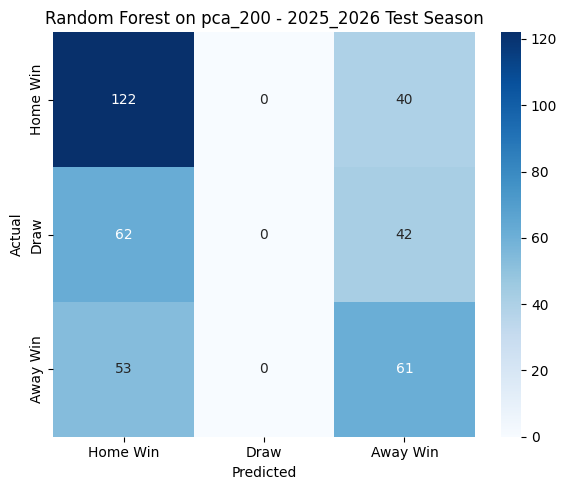

In [18]:
print("Selected reduction:", best_validation_row["reduction"])
print("Selected representation:", best_representation_name)
print("Selected model:", best_model_name)
print("Selected params:", best_params)
print("Final test metrics:", final_test_metrics)

plot_confusion_matrix_from_predictions(
    y_test,
    final_test_pred,
    title=f"{best_model_name} on {best_representation_name} - 2025_2026 Test Season",
)

## 20. Notes

- PCA is the linear dimensionality reduction method and is tested across component counts sized for the full feature set.
- The autoencoder is the nonlinear dimensionality reduction method and is tuned across bottleneck size, architecture, activation, and regularization on the full numeric feature set.
- The all-feature setup currently uses every numeric pre-match column after excluding IDs, target labels, and same-match result columns.
- XGBoost is included in the code path. If `XGBoost available` is `False`, install `xgboost` and rerun this notebook to include it in model tuning.